### Data description
There are 3 types of input features:

*Objective*: factual information;
*Examination*: results of medical examination;
*Subjective*: information given by the patient.

#### Features:

* Age | Objective Feature | age | int (days)
* Height | Objective Feature | height | int (cm) |
* Weight | Objective Feature | weight | float (kg) |
* Gender | Objective Feature | gender | categorical code |
* Systolic blood pressure | Examination Feature | ap_hi | int |
* Diastolic blood pressure | Examination Feature | ap_lo | int |
* Cholesterol | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal |
* Glucose | Examination Feature | gluc | 1: normal, 2: above normal, 3: well above normal |
* Smoking | Subjective Feature | smoke | binary |
* Alcohol intake | Subjective Feature | alco | binary |
* Physical activity | Subjective Feature | active | binary |
* Presence or absence of cardiovascular disease | Target Variable | cardio | binary |

All of the dataset values were collected at the moment of medical examination.

In [3]:
# import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import os

data = pd.read_csv(os.path.join("data/raw/cardio_train.csv"))

# Data exploration

print(data.columns)
# Null values : no null values in the dataset
# print(data.isnull().sum())
# Negative Values : 
print((data < 0).sum())
# print(pd.concat([data.head(5), data.sample(5), data.tail(5)]))

print(data.describe(include="all").transpose())


Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')
id             0
age            0
gender         0
height         0
weight         0
ap_hi          7
ap_lo          1
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
               count          mean           std      min       25%      50%  \
id           70000.0  49972.419900  28851.302323      0.0  25006.75  50001.5   
age          70000.0  19468.865814   2467.251667  10798.0  17664.00  19703.0   
gender       70000.0      1.349571      0.476838      1.0      1.00      1.0   
height       70000.0    164.359229      8.210126     55.0    159.00    165.0   
weight       70000.0     74.205690     14.395757     10.0     65.00     72.0   
ap_hi        70000.0    128.817286    154.011419   -150.0    120.00    120.0   
ap_lo        70000.0     96.630414    188.472530   

In [4]:

# Unsual BP values
# Systolic > 250 mmHg and Diastolic > 150 mmHg are considered extremely high and may indicate a hypertensive crisis, which is a medical emergency. Such high blood pressure readings can lead to severe health complications, including stroke, heart attack, or organ damage. It is crucial for individuals with such readings to seek immediate medical attention to manage their blood pressure and prevent potential life-threatening consequences.
print(data[data["ap_hi"] > 250].shape[0])
print(data[data["ap_lo"] > 150].shape[0])
print((data["ap_hi"] < 70).sum())
print((data["ap_lo"] < 40).sum())
print((data["ap_lo"] > data["ap_hi"]).sum())

# Getting ranges
high_sys = data[data["ap_hi"] > 250]["ap_hi"]
print("Systolic >250 range:", high_sys.min(), "to", high_sys.max())

high_dia = data[data["ap_lo"] > 150]["ap_lo"]
print("Diastolic >150 range:", high_dia.min(), "to", high_dia.max())

# Print where ap_hi < ap_lo -> not possible
print(data[data["ap_hi"] < data["ap_lo"]].shape[0])
data["age_years"] = (data["age"] / 365.25).round().astype(int)
data["gender"] = data["gender"].replace({1: 0, 2: 1})# 0=female, 1=male
# print(data["gender"].unique())          # should be [0, 1]

# print("Gender vales", data["gender"].value_counts()) 
# print(data["gender"].isnull().sum())

40
975
189
59
1234
Systolic >250 range: 309 to 16020
Diastolic >150 range: 160 to 11000
1234


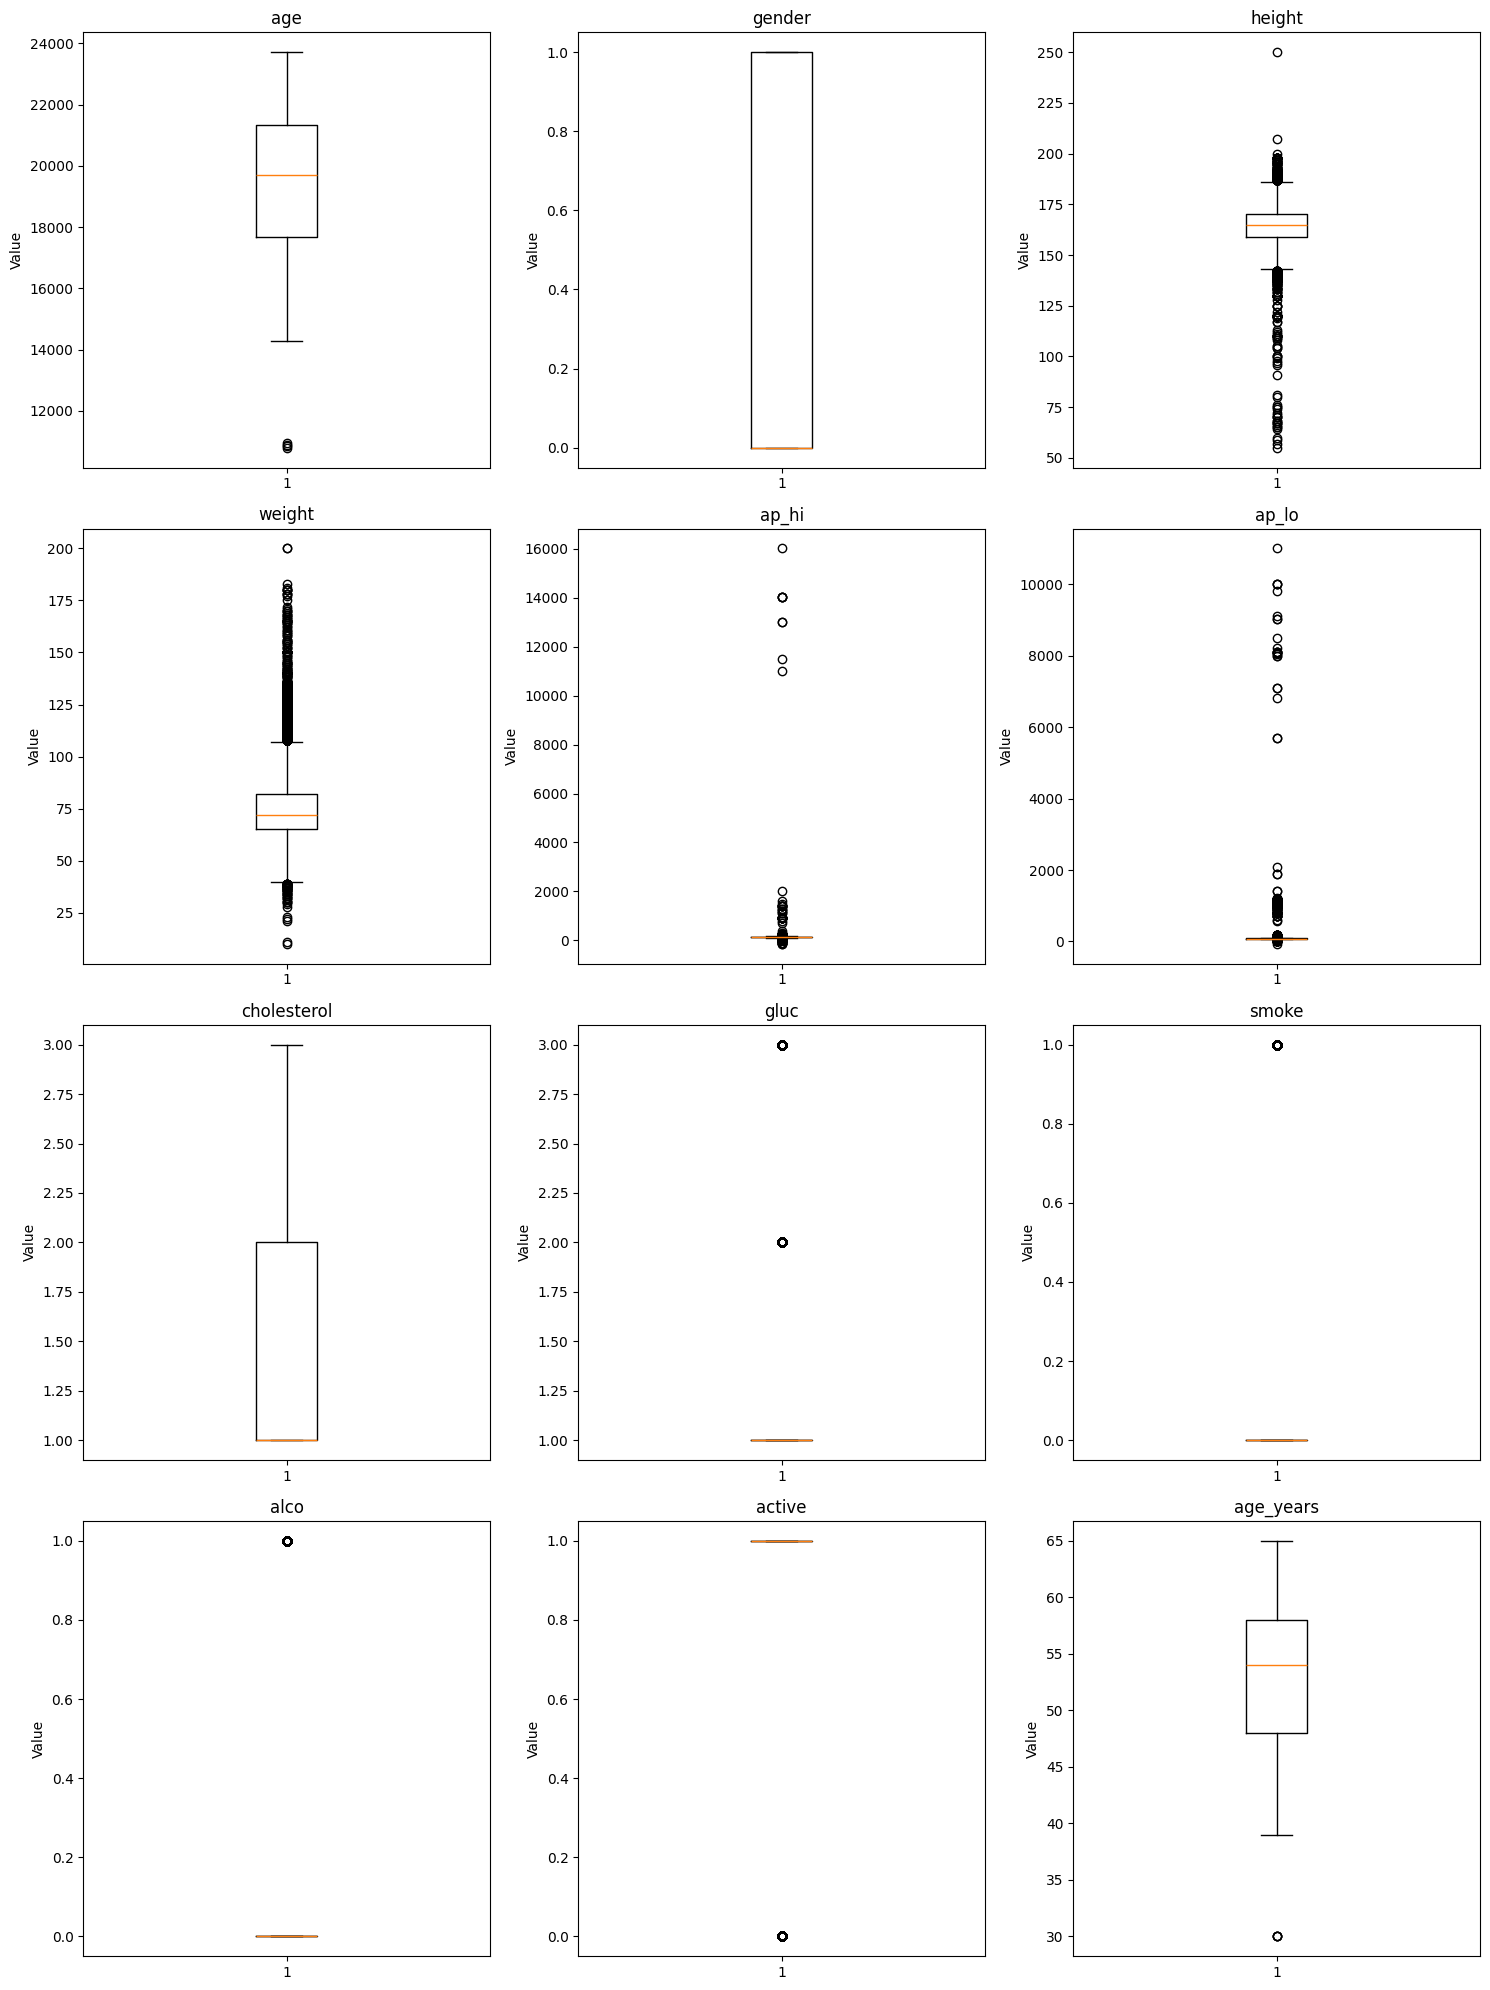

In [5]:
# Outliers - Box plots
import matplotlib.pyplot as plt
import numpy as np

# Drop target and ID (ID should not be analysed)
features = data.drop(columns=["cardio", "id"])

# Select only numeric columns
numeric_cols = features.select_dtypes(include=["int64", "float64"]).columns

# Determine grid size
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(features[col], vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:

# Define outlier thresholds and filter

df = data.copy()

# --- If you already converted age to years and renamed it ---
# If your column is still "age" in days, convert first:
# df["age_years"] = df["age"] / 365.25

# If you already have age in years in df["age"], then do:
# df["age_years"] = df["age"]

# 1) Create/ensure age_years exists (adjust this line to your setup)


def apply_filter(df, mask, name):
    before = df.shape[0]
    df = df[mask].copy()
    after = df.shape[0]
    print(f"{name:35s} | kept {after:6d}/{before:6d} | removed {before - after:6d}")
    return df

# --- Age filter ---
df = apply_filter(df, (df["age_years"] >= 30) & (df["age_years"] <= 65), "Age 30–65 years")

# --- Height & weight filters ---
df = apply_filter(df, (df["height"] >= 120) & (df["height"] <= 220), "Height 120–220 cm")
df = apply_filter(df, (df["weight"] >= 45) & (df["weight"] <= 200), "Weight 30–200 kg")

# --- Blood pressure filters ---
df = apply_filter(df, (df["ap_hi"] >= 70) & (df["ap_hi"] <= 200), "Systolic (ap_hi) 70–200")
df = apply_filter(df, (df["ap_lo"] >= 40) & (df["ap_lo"] <= 150), "Diastolic (ap_lo) 40–150")
df = apply_filter(df, df["ap_lo"] <= df["ap_hi"], "Diastolic <= Systolic")

# --- Cholesterol & glucose allowed values ---
df = apply_filter(df, df["cholesterol"].isin([1, 2, 3]), "Cholesterol in {1,2,3}")
df = apply_filter(df, df["gluc"].isin([1, 2, 3]), "Glucose in {1,2,3}")

# --- Lifestyle & target must be binary ---
for col in ["smoke", "alco", "active", "cardio"]:
    df = apply_filter(df, df[col].isin([0, 1]), f"{col} in {{0,1}}")

df = df.drop(columns=["id", "age"])  # Drop the ID
print("\nFinal cleaned shape:", df.shape)


Age 30–65 years                     | kept  70000/ 70000 | removed      0
Height 120–220 cm                   | kept  69947/ 70000 | removed     53
Weight 30–200 kg                    | kept  69645/ 69947 | removed    302
Systolic (ap_hi) 70–200             | kept  69360/ 69645 | removed    285
Diastolic (ap_lo) 40–150            | kept  68356/ 69360 | removed   1004
Diastolic <= Systolic               | kept  68270/ 68356 | removed     86
Cholesterol in {1,2,3}              | kept  68270/ 68270 | removed      0
Glucose in {1,2,3}                  | kept  68270/ 68270 | removed      0
smoke in {0,1}                      | kept  68270/ 68270 | removed      0
alco in {0,1}                       | kept  68270/ 68270 | removed      0
active in {0,1}                     | kept  68270/ 68270 | removed      0
cardio in {0,1}                     | kept  68270/ 68270 | removed      0

Final cleaned shape: (68270, 12)


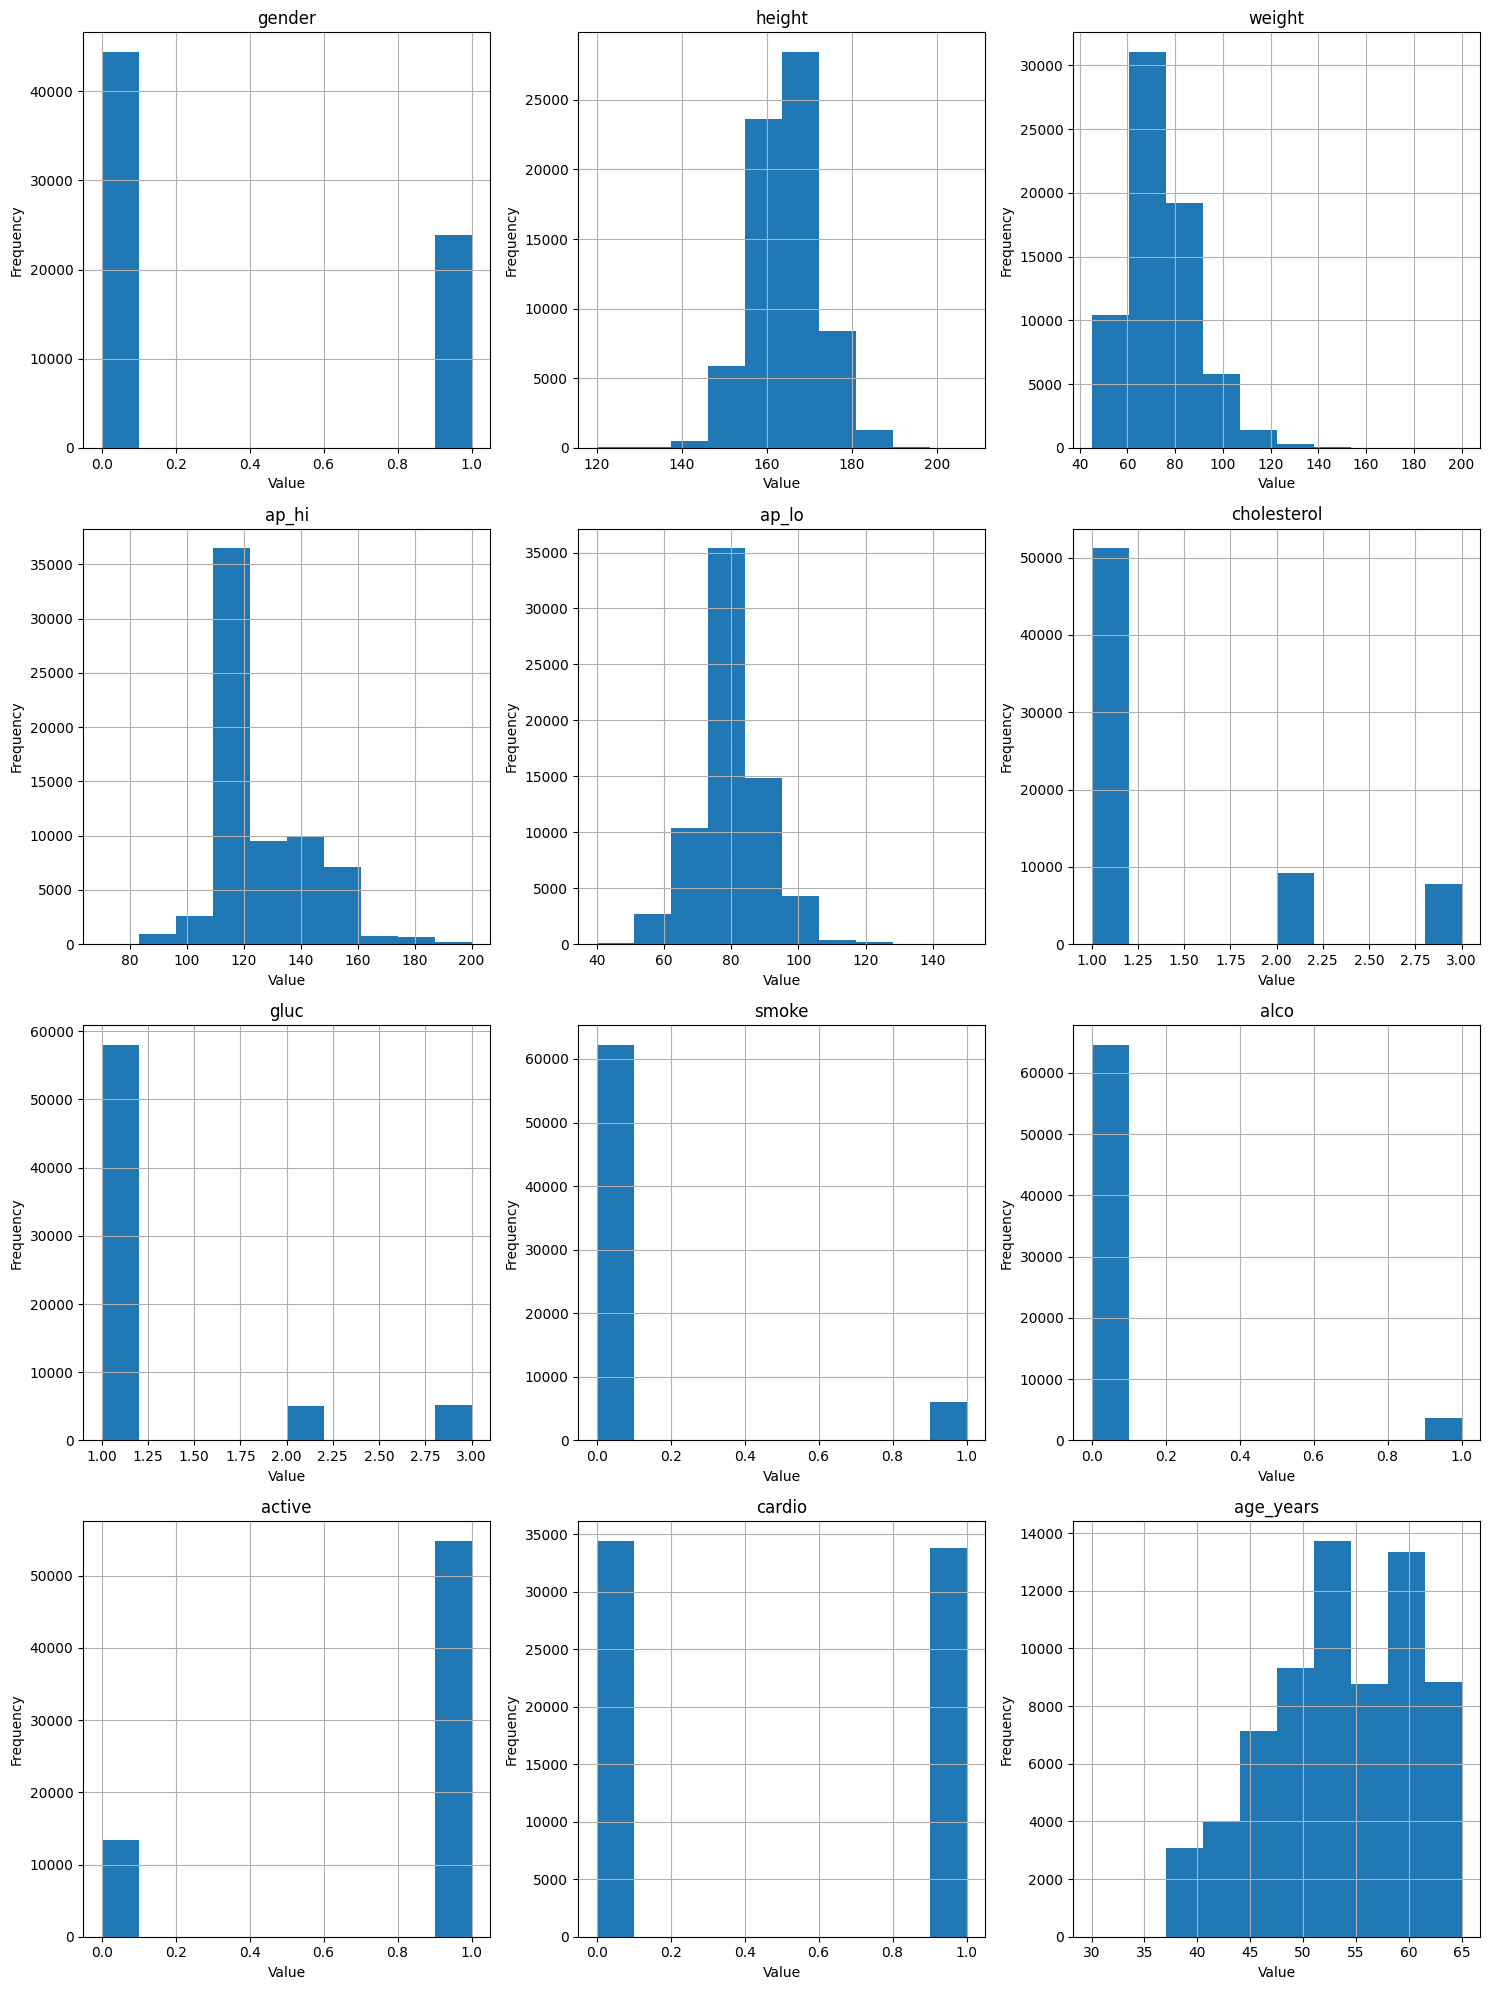

In [7]:
# Histograms for each feature
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

fig, axes = plt.subplots(nrows = 4, ncols = 3, figsize=(15, 20))

axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    df[col].hist(ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    
plt.tight_layout()
plt.show()



## Gender based Histograms to see more imbalance

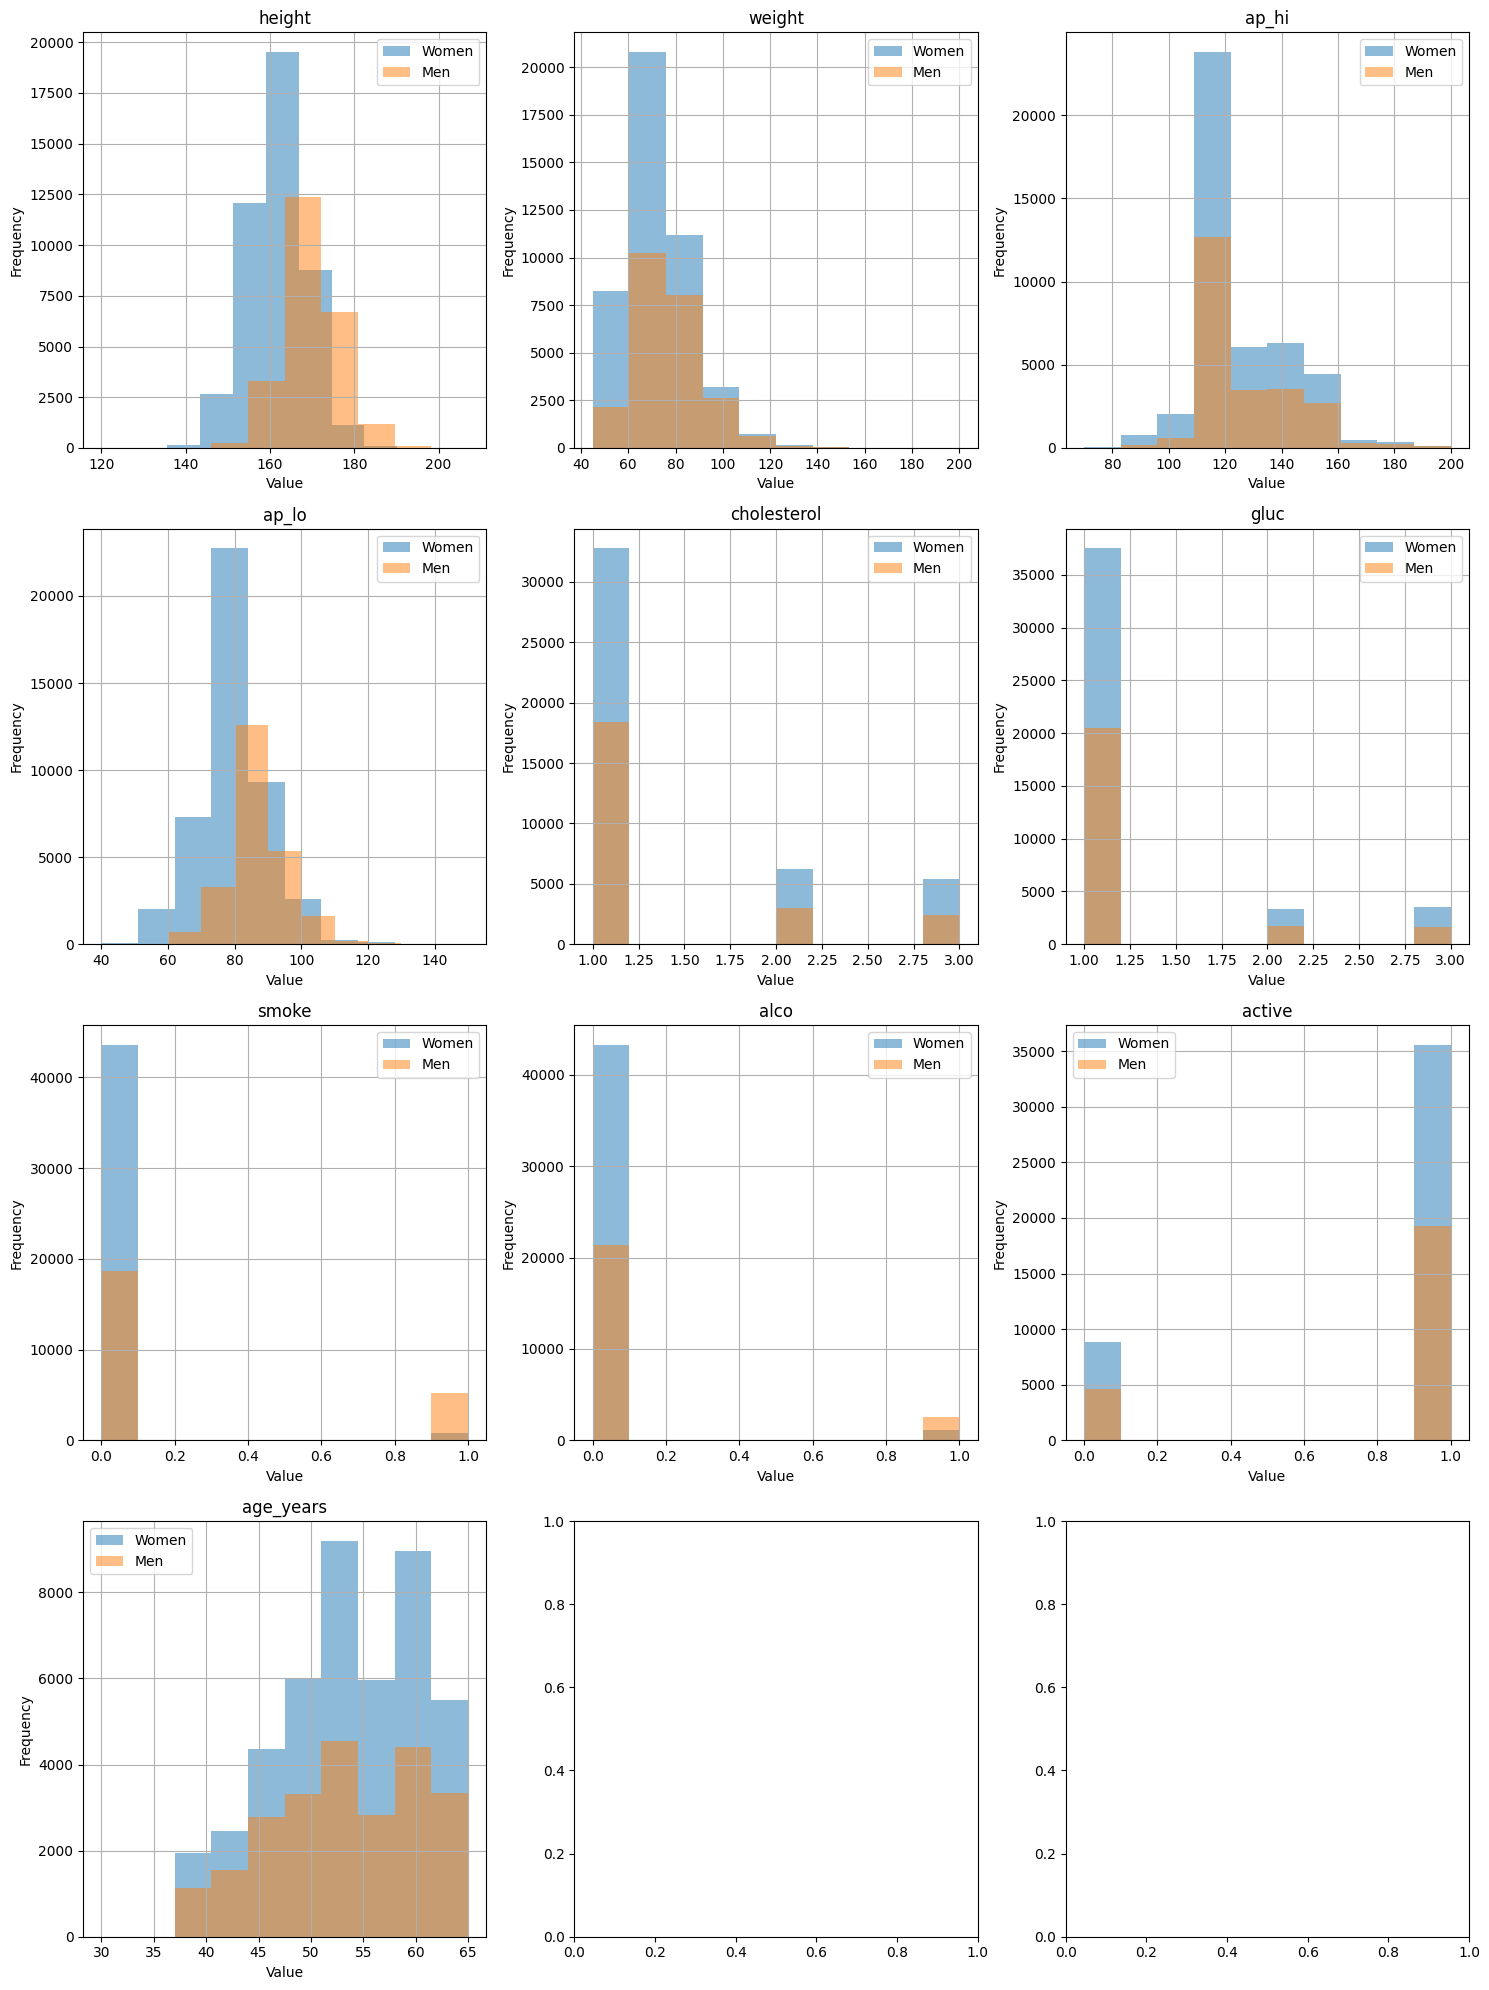

In [13]:
# --- Histograms by gender ---
numeric_cols = [c for c in numeric_cols if c not in ["gender"]]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    df[df["gender"] == 0][col].hist(ax=axes[idx], alpha=0.5, label="Women")
    df[df["gender"] == 1][col].hist(ax=axes[idx], alpha=0.5, label="Men")

    axes[idx].set_title(col)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [8]:
df.to_csv("data/processed/cardio_baseline_clean.csv", index=False)

print(df.groupby("smoke")["cardio"].mean())
print(df.groupby("alco")["cardio"].mean())
print(df.groupby("gluc")["cardio"].mean())
print(df.groupby("cholesterol")["cardio"].mean())

smoke
0    0.498088
1    0.468272
Name: cardio, dtype: float64
alco
0    0.496526
1    0.476569
Name: cardio, dtype: float64
gluc
1    0.476360
2    0.589204
3    0.617947
Name: cardio, dtype: float64
cholesterol
1    0.436217
2    0.597251
3    0.762573
Name: cardio, dtype: float64


In [17]:
print(pd.crosstab(df["gender"], df["cholesterol"], normalize="index"))
print(pd.crosstab(df["gender"], df["gluc"], normalize="index"))

df.groupby("gender")[["smoke","alco","active"]].mean()

cholesterol         1         2         3
gender                                   
0            0.738382  0.139842  0.121776
1            0.771370  0.126942  0.101688
gluc           1         2         3
gender                              
0       0.845066  0.074899  0.080035
1       0.859530  0.071785  0.068685


,smoke,alco,active
gender,,,
0,0.017705,0.025207,0.801410
1,0.219207,0.105960,0.806299


* Cholesterol - Proportions similar across gender (women have slightly higher chol in dataset - very less difference)
* Glucose - also similar - More women in category 3, minor difference tho
* Smoking - Huge difference - 1.8 % women are smokers compared to 21.9% men being smokers (Men smoke 12x more often) - Model learns strong gender correlation
* Alcohol - 2.5% women drink alcohol, 10.6% men drink alcohol (Men drink 4x more)
**Note** - Since Smoking and Alcohol are self reported, due to social implications women are likely to underreport their habits so this is not as unreliable - might have to look into how to deal with this lol
* Physical Activity - Similar again

## Different Feature combinations
1. BSA 
2. Pulse pressure?
3. Health indicator maybe

Will need to see indicators



In [9]:
# Adding BSA
df['BSA'] = df['weight']/(df['height']*df['height'])
df['Pulse pressure'] = df['ap_hi'] - df['ap_lo']

df.to_csv("data/processed/cardio_bsa_pp.csv", index=False)